In [1]:
import jax
import numpy as np
import cotengra as ctg
import quimb.tensor as qtn
import quimb as qu
from concurrent.futures import ThreadPoolExecutor
import sys
import tqdm
from functools import reduce
from itertools import product

In [2]:
seed = 666

In [3]:
def Q_to_Ising(qubo_matrix, O):
    n_qubits = qubo_matrix.shape[0]
    J = {}
    h = {i : 0 for i in range(n_qubits)}
    # zi^2 = 1
    for i in range(n_qubits):
        # Q[i, i]xi^2 = Q[i, i](1 - 2zi + zi^2)/4 -> h[i] = - Q[i, i]/ 2, O += Q[i, i] / 2
        h[i] -= qubo_matrix[i, i] / 2
        O += qubo_matrix[i, i] / 2
        # Calculate pairwise interactions
        for j in range(i + 1, n_qubits):
            # Q[i, j]xi xj = Q[i, j] (1 - zi - zj + zi zj)/4 -> J[i, j] = Q[i, j] / 4, h[i], h[j] -= Q[i, j]/4, O+= Q[i, j] / 4
            J[(i, j)] = qubo_matrix[i, j] / 4
            h[i] -= qubo_matrix[i, j] / 4
            h[j] -= qubo_matrix[i, j] / 4
            O += qubo_matrix[i, j] / 4
    return h, J, O

In [4]:
data = np.load('/lustre/scratch127/qpg/jc59/out/tangle/qubo_data_trivial.gfa.npy', allow_pickle=True)
Q, offset, T, W = data
# Move terms to upper triangular part
Q = np.triu(Q) * 2
Q -= np.triu(np.triu(Q).T) / 2
N_vars = Q.shape[0]

# Get Hamiltonian terms
h, J, offset = Q_to_Ising(Q, offset)

In [5]:
p = 2
gammas = qu.randn(p, seed=seed)
betas = qu.randn(p, seed=seed)
circ = qtn.circ_qaoa(h, J, p, gammas, betas)
circ_V = circ.uni
circ_psi = circ.psi

/nfs/users/nfs_j/jc59/quantumwork/pangenome/modules/quimb_fork/quimb/tensor/circuit.py:2422: FutureWarning: In future the tensor network returned by ``circ.uni`` will not be transposed as it is currently, to match the expectation from ``U = circ.uni.to_dense()`` behaving like ``U @ psi``. You can retain this behaviour with ``circ.get_uni(transposed=True)``.
  warnings.warn(


In [6]:
def energy(psi, H):
    return psi.H @ H @ psi

In [7]:
def normalize_state(psi):
    return psi / (psi.H @ psi) ** 0.5

In [26]:
# This is possibly very slow
N_vars = Q.shape[0]
d = 2 ** N_vars
ham = np.zeros((d, d), dtype=complex)
for edge, weight in list(J.items()):
    Z_op = np.diagflat([(-1) ** (i[edge[0]] + i[edge[1]]) for i in product([0, 1], repeat=N_vars)])
    ham += weight * Z_op
for i, weight in list(h.items()):
    Z_op = np.diagflat([(-1) ** (j[i]) for j in product([0, 1], repeat=N_vars)])
    ham += weight * Z_op
ham = qu.qarray(ham)


(0, 1)
(0, 2)


TypeError: reduce() of empty iterable with no initial value

In [9]:
ham_tn = qtn.Tensor(data=ham.reshape(([2] * 2 * N_vars)), inds=[f'k{i}' for i in range(N_vars)] + [f'b{i}' for i in range(N_vars)], tags={'HAM'})

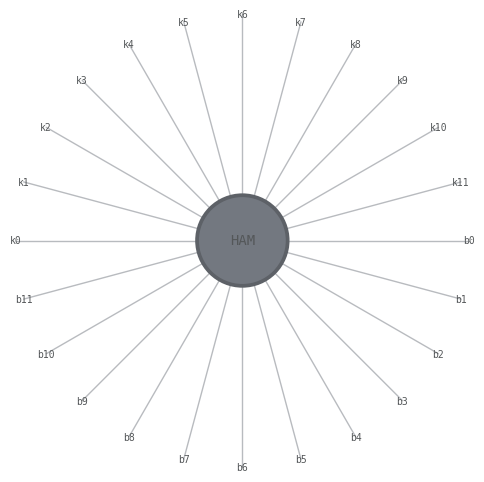

In [10]:
ham_tn.draw(show_inds=True)

In [17]:
qu.expectation(circ_psi, ham)

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)

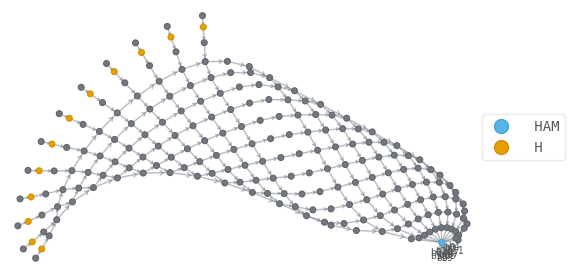

In [13]:
(ham_tn & circ_psi).draw(show_inds=True, color=['HAM', 'H'])

In [ ]:
energy(circ_psi, ham_tn)

In [ ]:
tnoptimizer = qtn.TNOptimizer(
    circ_psi,
    loss_fn=energy,
    norm_fn=normalize_state,
    loss_constants={'H': ham},
    tags=[f'ROUND_{i+1}' for i in range(p)],
    autodiff_backend='autograd'
)

In [ ]:
psi_opt = tnoptimizer.optimize_basinhopping(n=10, nhop=10)